In [33]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [5]:
sample_mean = 495
sample_std = 10
n = 25
mu_0 = 500
alpha = 0.05

In [8]:
t_statistic = (sample_mean - mu_0) / (sample_std / (n ** 0.5))
df = n - 1
p_value = stats.t.cdf(t_stat, df)

In [10]:
if p_value < alpha:
    print(f"t-값: {t_statistic:.4f}, p-value: {p_value:.4f}. 유의수준 {alpha}에서 귀무가설을 기각합니다. 빵의 평균 무게는 목표와 다릅니다.")
else:
    print(f"t-값: {t_statistic:.4f}, p-value: {p_value:.4f}. 유의수준 {alpha}에서 귀무가설을 채택합니다. 빵의 평균 무게는 목표와 통계적으로 차이가 없습니다.")

t-값: -2.5000, p-value: 0.0098. 유의수준 0.05에서 귀무가설을 기각합니다. 빵의 평균 무게는 목표와 다릅니다.


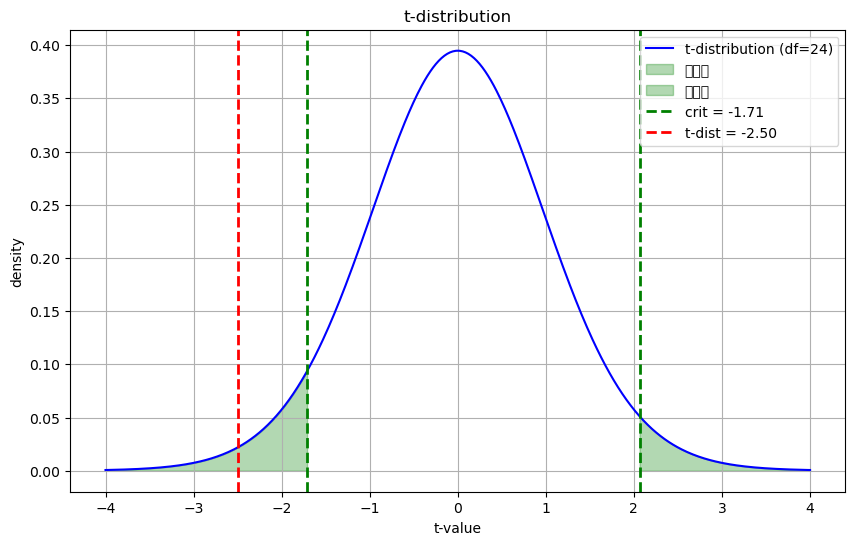

In [16]:
t_critical = t.ppf(alpha, df)
t_critical_right = t.ppf(1 - alpha / 2, df)

x = np.linspace(-4, 4, 500)
y = t.pdf(x, df)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='t-distribution (df=24)', color='blue')

x_fill = np.linspace(-4, t_critical, 200)
plt.fill_between(x_fill, t.pdf(x_fill, df), color='green', alpha=0.3, label='기각역')
x_right = np.linspace(t_critical_right, 4, 200)
plt.fill_between(x_right, t.pdf(x_right, df), color='green', alpha=0.3, label='기각역')

plt.axvline(t_critical, color='green', linestyle='--', linewidth=2, label=f'crit = {t_critical:.2f}')
plt.axvline(t_stat, color='red', linestyle='--', linewidth=2, label=f't-dist = {t_stat:.2f}')
plt.axvline(t_critical_right, color='green', linestyle='--', linewidth=2)

plt.title('t-distribution')
plt.xlabel('t-value')
plt.ylabel('density')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
sample_scores = [79, 77, 80, 76, 78, 81, 75, 79, 77, 80, 78, 76, 82, 77, 79, 78]
n = len(sample_scores)
mu_0 = 75

sample_mean = sum(sample_scores) / n
sample_std = stats.tstd(sample_scores)

t_stat = (sample_mean - mu_0) / (sample_std / (n ** 0.5))

df = n - 1

p_value = 1 - stats.t.cdf(t_stat, df)



if p_value < alpha:
    print(f"t-값: {t_stat:.4f}, p-value: {p_value:.4f}. 유의수준 {alpha}에서 귀무가설을 기각합니다. 교육프로그램은 효과가 있습니다.")
else:
    print(f"t-값: {t_stat:.4f}, p-value: {p_value:.4f}. 유의수준 {alpha}에서 귀무가설을 채택합니다. 교육프로그램은 효과가 없습니다")

t-값: 6.7890, p-value: 0.0000. 유의수준 0.05에서 귀무가설을 기각합니다. 교육프로그램은 효과가 있습니다.


In [25]:
group_A = [5.1, 4.7, 6.2, 4.9, 5.3, 6.1, 5.0, 5.8, 4.8, 5.2]
group_B = [4.3, 4.1, 3.8, 4.6, 4.0, 4.5, 3.7, 4.2, 3.9, 4.4, 3.5, 4.3]


t_stat, p_value = stats.levene(group_A, group_B)
alpha = 0.05

if p_value < 0.05:
    equal_var = False
else:
    equal_var = True

t_stat, p_val = stats.ttest_ind(group_A, group_B, equal_var=equal_var)


if p_value < alpha:
    print(f"t-값: {t_stat:.4f}, p-value: {p_val:.4f}. 유의수준 {alpha}에서 귀무가설을 기각합니다. 다이어트 프로그램은 효과가 있습니다.")
else:
    print(f"t-값: {t_stat:.4f}, p-value: {p_val:.4f}. 유의수준 {alpha}에서 귀무가설을 채택합니다. 다이어트 프로그램은 효과가 없습니다")

t-값: 6.3898, p-value: 0.0000. 유의수준 0.05에서 귀무가설을 채택합니다. 다이어트 프로그램은 효과가 없습니다


In [26]:
before = np.array([70, 80, 65, 90, 75, 85, 78, 82, 68, 73])
after = np.array([68, 78, 64, 88, 74, 83, 77, 80, 67, 72])

diff = before - after

t_stat, p_value = stats.ttest_rel(before, after)

p_value_one_tailed = p_value / 2

if p_value < alpha:
    print(f"t-값: {t_stat:.4f}, p-value: {p_value:.4f}. 유의수준 {alpha}에서 귀무가설을 기각합니다. 고혈압약은 효과가 있습니다.")
else:
    print(f"t-값: {t_stat:.4f}, p-value: {p_value:.4f}. 유의수준 {alpha}에서 귀무가설을 채택합니다. 고혈압약은 효과가 없습니다.")



t-값: 9.0000, p-value: 0.0000. 유의수준 0.05에서 귀무가설을 기각합니다. 고혈압약은 효과가 있습니다.


In [34]:
data = pd.read_excel("online_retail_II.xlsx", sheet_name='Year 2009-2010')
data2 = pd.read_excel("online_retail_II.xlsx", sheet_name='Year 2010-2011')
retail = pd.concat([data, data2])

In [35]:
retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [36]:
uk_data = retail[retail['Country'] == 'United Kingdom'].copy()
uk_data['TotalPrice'] = uk_data['Quantity'] * uk_data['Price']

In [37]:
uk_data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,23.4
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,23.6
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,30.0
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,214.8


In [38]:
population_mean = uk_data['TotalPrice'].mean()

In [42]:
np.random.seed(42)
sample_sizes = [30, 100, 300]
for size in sample_sizes:
    sample = uk_data['TotalPrice'].sample(n=size)
    sample_mean = sample.mean()
    print(f"sample size {size}: {sample_mean:.2f}")

sample size 30: 11.88
sample size 100: 12.99
sample size 300: 17.14


In [45]:
# 신뢰 구간 계산 함수
def confidence_interval(data, confidence=0.95):
    mean = data.mean()
    std_err = stats.sem(data)
    interval = stats.t.interval(confidence, len(data)-1, loc=mean, scale=std_err)
    return mean, interval

# 샘플 크기에 따른 신뢰 구간 비교
ample_sizes = [30, 100, 300]
for size in sample_sizes:
    sample = uk_data['TotalPrice'].sample(size, random_state=42)
    mean, interval = confidence_interval(sample)
    print(f" Sample size: {size}")
    print(f"    Mean: {mean:.2f}")
    print(f"    95% 신뢰구간: ({interval[0]:.2f}, {interval[1]:.2f})")
    print(f"    신뢰구간 길이: {interval[1] - interval[0]:.2f}\n")

 Sample size: 30
    Mean: 11.88
    95% 신뢰구간: (6.38, 17.38)
    신뢰구간 길이: 11.01

 Sample size: 100
    Mean: 16.09
    95% 신뢰구간: (11.14, 21.03)
    신뢰구간 길이: 9.88

 Sample size: 300
    Mean: 13.34
    95% 신뢰구간: (11.26, 15.42)
    신뢰구간 길이: 4.16



In [47]:
retail['TotalPrice'] = retail['Quantity'] * retail['Price']

uk_data = retail[retail['Country'] == 'United Kingdom']['TotalPrice'].dropna()
germany_data = retail[retail['Country'] == 'Germany']['TotalPrice'].dropna()

In [48]:
uk_data = uk_data[uk_data > 0]
germany_data = germany_data[germany_data > 0]

In [52]:
uk_data

0          83.4
1          81.0
2          81.0
3         100.8
4          30.0
          ...  
541889     23.4
541890     23.6
541891     30.0
541892    214.8
541893     70.8
Name: TotalPrice, Length: 958502, dtype: float64

In [53]:
germany_data

579       15.00
580       13.20
581       10.50
582       19.80
583       15.00
          ...  
541801    15.00
541802    10.20
541803    10.20
541804    24.96
541805    16.50
Name: TotalPrice, Length: 16694, dtype: float64

In [55]:
t_stat, p_value = stats.ttest_ind(uk_data, germany_data, equal_var=True)
alpha = 0.05

In [56]:
print(f"t_stat: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t_stat: -4.4254
p-value: 0.0000


In [60]:
if p_value < alpha:
    print("영국과 독일 고객의 평균 구매 금액에 유의한 차이가 있습니다.")
else:
    print("영국과 독일 고객의 평균 구매 금액에 유의한 차이가 없습니다.")

영국과 독일 고객의 평균 구매 금액에 유의한 차이가 있습니다.


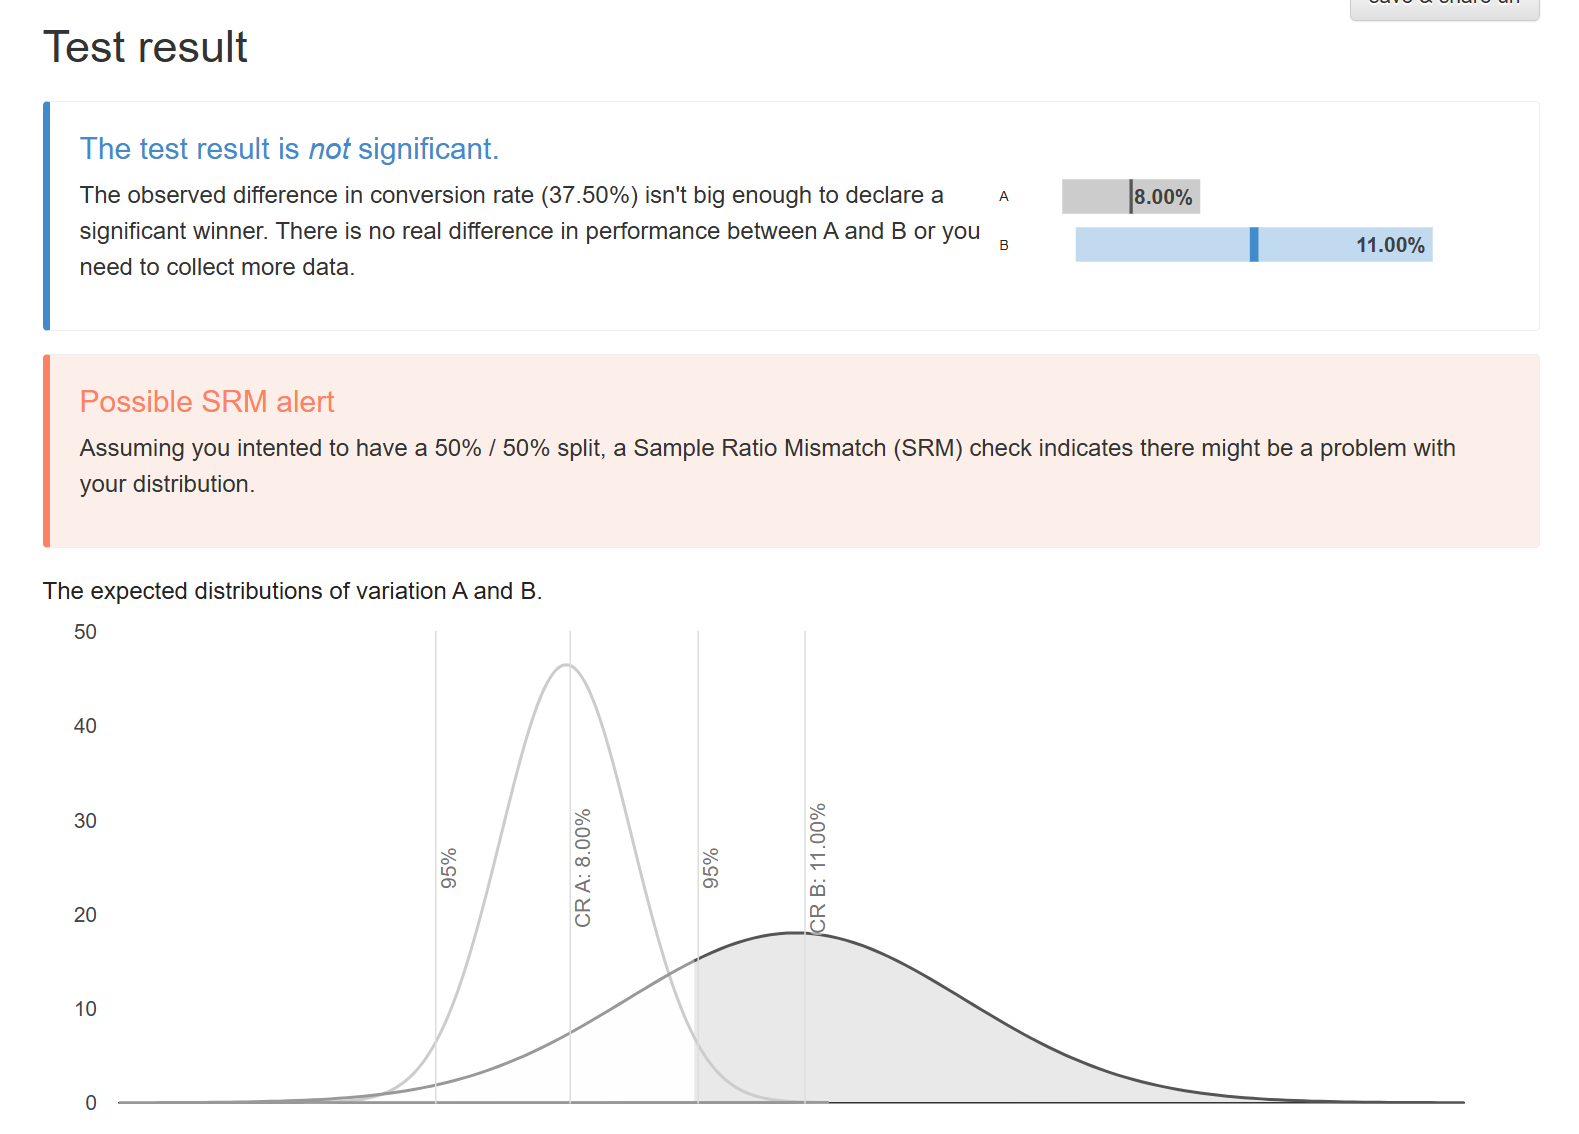

페이지 B의 표본수가 부족하거나 유의미한 차이가 없다고 보여진다.

##A/B 테스트의 결과가 통계적으로 유의하나 효과의 차이 자체는 매우 작은 경우, 어떤 의사결정을 할 수 있을지 사례를 통해 설명해 주세요.


만약 A/B 테스트의 결과가 (P-Value = 0.05 가정) 통계적으로 유의하나 효과의 차이 자체가 매우 작은 경우에 여러가지를 고려하여 의사결정을 할 수 있다. 우선 효과의 크기 자체는 매우 작으므로 무시할 수 있지만, 그 플랫폼의 사용자수가 아주 많고 드는 비용의 크기에 차이가 있을 경우 효과의 차이가 매우 작아도 이를 적용하는 의사결정을 내릴 수 있다. 반대로, 통계적으로 유의하지만 드는 비용의 차이가 없고 사용자수가 그렇게 크지 않다면 원래 방식을 유지하는 의사결정을 내릴 수 있는 근거가 될 수 있다.